<a href="https://colab.research.google.com/github/yizhenhong9-alt/AIoT_DA_HW2/blob/main/Red_Wine_Quality_CRISPDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 紅酒品質預測（最終強化版）

以 **CRISP-DM** 方法論為架構，使用 `scikit-learn`（及可選的 XGBoost）比較多種回歸模型，並加入特徵選取、完整評估與含 95% 信賴區間的預測視覺化。註解與段落以**繁體中文**為主，適合作為課程報告或作業交付檔案。

## Step 1：專案目的與業務理解（Business Understanding）

**目的**：根據葡萄酒的化學特徵預測其感官評分（quality，數值式），協助品質控管與生產優化。

**成果預期**：建立可解釋且效能良好的迴歸模型（包含模型比較）、指出重要特徵、並提供模型部署範例。

In [1]:
# Step 2：環境與套件 (Imports)
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    XGBRegressor = None
    xgb_available = False
    print('xgboost not available, will skip XGBoost model.')

print('Imports done')

Imports done


In [2]:
# Step 2：資料載入
import glob
candidates = glob.glob('/content/winequality-red.csv', recursive=True) + glob.glob('/content/winequality-red.csv', recursive=True)
if not candidates:
    candidates = glob.glob('/content/winequality-red.csv', recursive=True) + glob.glob('/content/winequality-red.csv', recursive=True)

if candidates:
    data_path = candidates[0]
else:
    data_path = 'winequality-red.csv'

print('使用資料：', data_path)

df = pd.read_csv(data_path, sep=',')
print('資料 shape:', df.shape)
df.head()

使用資料： /content/winequality-red.csv
資料 shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# EDA: info, describe, missing
print('\nData info:')
df.info()
print('\nDescribe:')
display(df.describe().T)
print('\nMissing values:')
print(df.isnull().sum())


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Describe:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000



Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


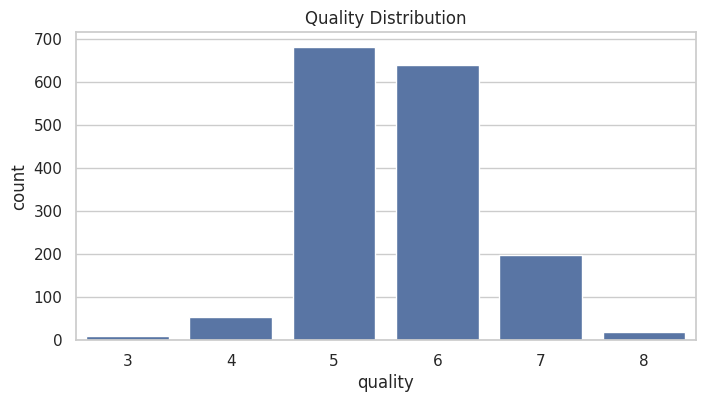

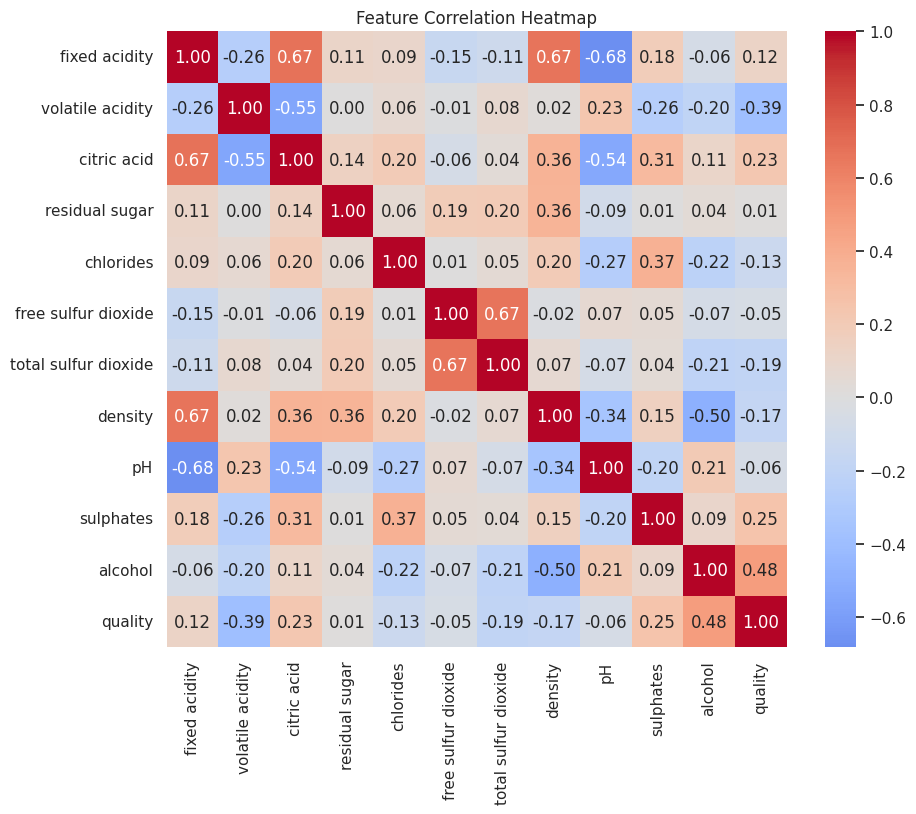

In [4]:
# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))
sns.countplot(x='quality', data=df)
plt.title('Quality Distribution')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [5]:
# Step 3: Data preparation
X = df.drop('quality', axis=1)
y = df['quality']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print('Train shape after scaling:', X_train.shape)
print('Test shape after scaling:', X_test.shape)

Train shape after scaling: (1279, 11)
Test shape after scaling: (320, 11)


Selected features: ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


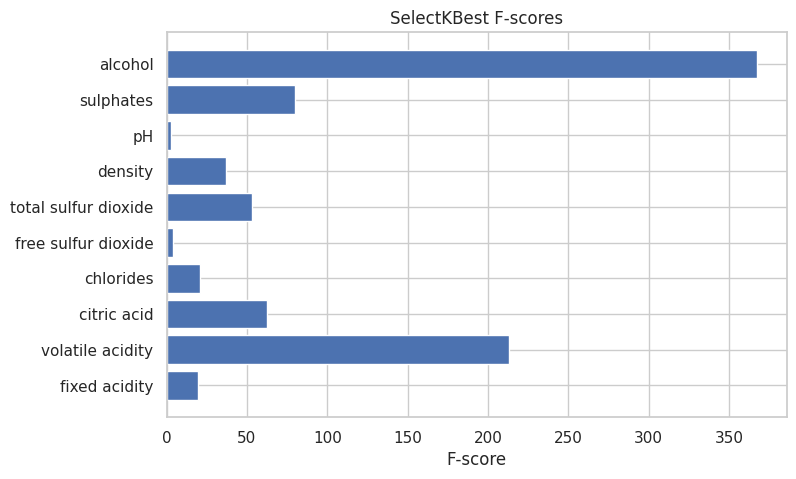

In [6]:
# Step 4.5: Feature Selection (SelectKBest)
from sklearn.feature_selection import SelectKBest, f_regression
K = 10
selector = SelectKBest(score_func=f_regression, k=K)
selector.fit(X_train, y_train)
selected = X_train.columns[selector.get_support()]
print('Selected features:', list(selected))

plt.figure(figsize=(8,5))
plt.barh(selected, selector.scores_[selector.get_support()])
plt.title('SelectKBest F-scores')
plt.xlabel('F-score')
plt.show()

X_train_sel = X_train[selected].copy()
X_test_sel = X_test[selected].copy()

In [7]:
# Step 4: Modeling - define models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}
try:
    from xgboost import XGBRegressor
    models['XGBoost'] = XGBRegressor(random_state=42, verbosity=0)
    print('XGBoost included')
except Exception:
    print('XGBoost not available')

print('Models to evaluate:', list(models.keys()))

XGBoost included
Models to evaluate: ['Linear', 'Ridge', 'Lasso', 'RandomForest', 'GradientBoosting', 'XGBoost']


In [8]:
# Quick cross-validation on selected features
from sklearn.model_selection import KFold, cross_val_score
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_summary = {}
for name, mdl in models.items():
    scores = cross_val_score(mdl, X_train_sel, y_train, cv=cv, scoring='r2', n_jobs=-1)
    cv_summary[name] = {'r2_mean': scores.mean(), 'r2_std': scores.std()}

import pandas as pd
cv_df = pd.DataFrame(cv_summary).T.sort_values('r2_mean', ascending=False)
display(cv_df)


,r2_mean,r2_std
RandomForest,0.445744,0.036549
GradientBoosting,0.394603,0.031690
XGBoost,0.381698,0.058025
Ridge,0.325898,0.025994
Linear,0.325820,0.026024
Lasso,-0.006129,0.004778


In [9]:
# GridSearch for tree-based models (small grids to keep compute reasonable)
from sklearn.model_selection import GridSearchCV
best_models = {}
param_grids = {
    'RandomForest': {'n_estimators':[100], 'max_depth':[6,10]},
    'GradientBoosting': {'n_estimators':[100], 'learning_rate':[0.05,0.1], 'max_depth':[3,5]}
}
if 'XGBoost' in models:
    param_grids['XGBoost'] = {'n_estimators':[100], 'learning_rate':[0.05,0.1], 'max_depth':[3,5]}

for name in ['RandomForest','GradientBoosting'] + (['XGBoost'] if 'XGBoost' in models else []):
    print('\nGridSearch for', name)
    grid = GridSearchCV(models[name], param_grids[name], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train_sel, y_train)
    print('Best params:', grid.best_params_)
    print('Best CV R2:', grid.best_score_)
    best_models[name] = grid.best_estimator_

# fit other models without extensive grid search
for name, mdl in models.items():
    if name not in best_models:
        mdl_fit = mdl.fit(X_train_sel, y_train)
        best_models[name] = mdl_fit

print('\nBest models keys:', list(best_models.keys()))


GridSearch for RandomForest
Best params: {'max_depth': 10, 'n_estimators': 100}
Best CV R2: 0.42665776571782005

GridSearch for GradientBoosting
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best CV R2: 0.3880457650256613

GridSearch for XGBoost
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best CV R2: 0.41351780891418455

Best models keys: ['RandomForest', 'GradientBoosting', 'XGBoost', 'Linear', 'Ridge', 'Lasso']


In [11]:
# Step 5: Evaluation on test set
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
results = []
for name, mdl in best_models.items():
    y_pred = mdl.predict(X_test_sel)
    results.append({'Model': name,
                    'MAE': mean_absolute_error(y_test, y_pred),
                    'RMSE': mean_squared_error(y_test, y_pred)**0.5, # Calculate RMSE by taking the square root
                    'R2': r2_score(y_test, y_pred)})
res_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
display(res_df)

best_name = res_df.loc[0,'Model']
best_model = best_models[best_name]
print('Selected best model:', best_name)

,Model,MAE,RMSE,R2
0,RandomForest,0.440505,0.562021,0.516657
1,GradientBoosting,0.453110,0.582755,0.480336
2,XGBoost,0.460910,0.588601,0.469858
3,Linear,0.504088,0.625186,0.401906
4,Ridge,0.504126,0.625209,0.401862
5,Lasso,0.685284,0.810654,-0.005592


Selected best model: RandomForest


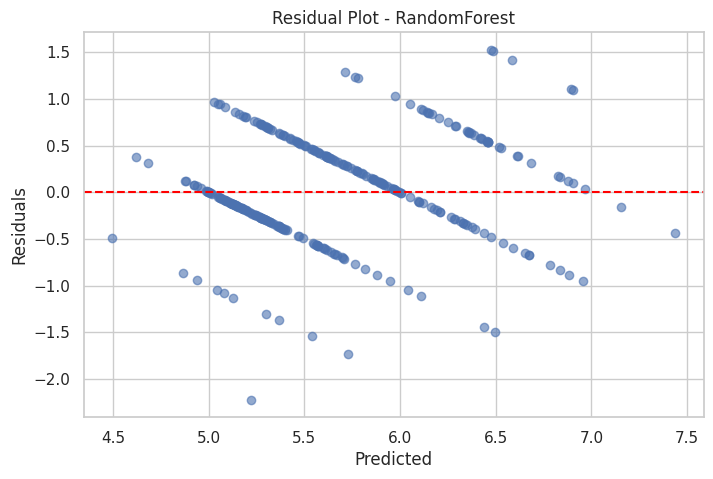

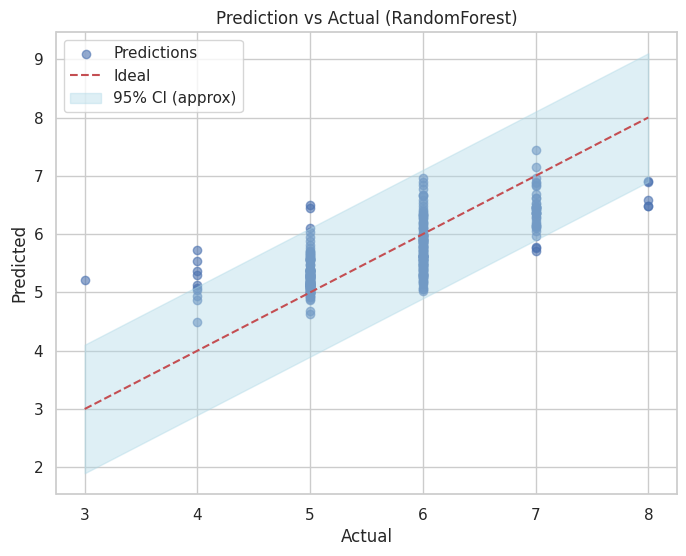

,Actual,Predicted,Residual
803,6,5.251653,0.748347
124,5,5.112599,-0.112599
350,6,5.399105,0.600895
682,5,5.193087,-0.193087
1326,6,5.953587,0.046413
976,5,5.108572,-0.108572
1493,5,5.160028,-0.160028
706,5,4.996163,0.003837
613,5,6.111848,-1.111848
1587,6,5.976217,0.023783


In [12]:
# Step 5.1: Residuals & Prediction Plot with 95% CI
import numpy as np

y_pred_best = best_model.predict(X_test_sel)
residuals = y_test - y_pred_best
sigma = residuals.std()
ci = 1.96 * sigma

# Residual plot
plt.figure(figsize=(8,5))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(f'Residual Plot - {best_name}')
plt.show()

# Prediction vs Actual with CI
x_line = np.linspace(y_test.min(), y_test.max(), 200)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.6, label='Predictions')
plt.plot(x_line, x_line, 'r--', label='Ideal')
plt.fill_between(x_line, x_line-ci, x_line+ci, color='lightblue', alpha=0.4, label='95% CI (approx)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Prediction vs Actual ({best_name})')
plt.legend()
plt.show()

# Show sample comparisons
comp = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_best, 'Residual': residuals})
display(comp.head(12))

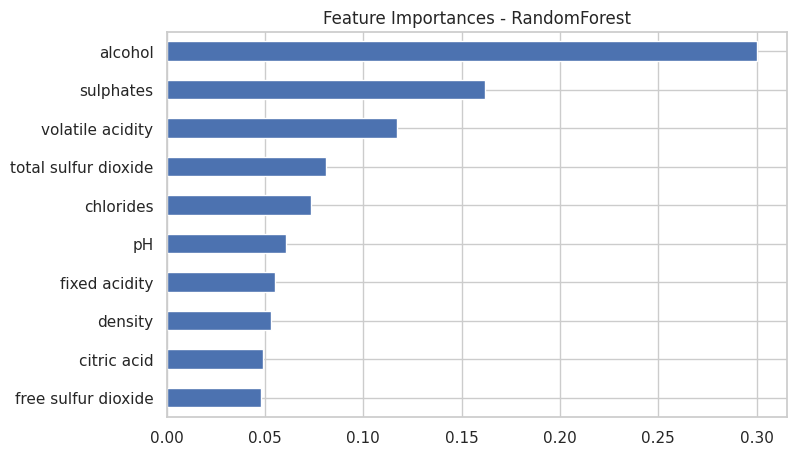

In [13]:
# Step 5.2: Feature importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X_train_sel.columns).sort_values(ascending=True)
    plt.figure(figsize=(8,5))
    fi.plot(kind='barh')
    plt.title(f'Feature Importances - {best_name}')
    plt.show()
else:
    from sklearn.inspection import permutation_importance
    r = permutation_importance(best_model, X_test_sel, y_test, n_repeats=30, random_state=42, n_jobs=-1)
    perm = pd.Series(r.importances_mean, index=X_test_sel.columns).sort_values(ascending=True)
    plt.figure(figsize=(8,5))
    perm.plot(kind='barh')
    plt.title(f'Permutation Importances - {best_name}')
    plt.show()

In [15]:
# Step 6: Save model & scaler
joblib.dump(best_model, '/content/best_wine_model_final.joblib')
joblib.dump(scaler, '/content/wine_scaler_final.joblib')
print('Saved model and scaler to /content/')

Saved model and scaler to /content/


## Step 7：Final Thoughts（最終心得與建議）

1. 建議使用更深入的超參數搜尋 (RandomizedSearch / Bayesian Optimization) 以進一步提升模型。
2. 若能取得更多元的特徵（例如葡萄品種、氣候、釀造流程）將有助於提升預測能力。
3. 建議使用 SHAP 進行模型可解釋性分析，以便精準掌握單一預測的驅動因子。

---

Notebook 已整理為 `Red_Wine_Quality_CRISPDM_Enhanced_Final.ipynb`，如需我執行部分 cell 並回傳圖表或數據摘要，請告訴我你想執行哪一段（例如：整個 notebook、或僅執行 GridSearch 與評估部份）。